In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
sns.set_theme()
import matplotlib.pyplot as plt


from sklearn import linear_model
#import models ...
import lightgbm as lgbm
import xgboost as xgb
from catboost import CatBoostClassifier
import torch


from sklearn.linear_model import Ridge
from sklearn.decomposition import PCA

from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

### Load files

In [2]:
X_train = pd.read_csv('X_train_9xQjqvZ.csv',index_col='ROW_ID')
X_test = pd.read_csv('X_test_1zTtEnD.csv',index_col='ROW_ID')

y_train = pd.read_csv('y_train_Ppwhaz8.csv',index_col='ROW_ID')

In [3]:
X_train.head()

,TS,ALLOCATION,RET_20,RET_19,RET_18,RET_17,RET_16,RET_15,RET_14,RET_13,...,SIGNED_VOLUME_8,SIGNED_VOLUME_7,SIGNED_VOLUME_6,SIGNED_VOLUME_5,SIGNED_VOLUME_4,SIGNED_VOLUME_3,SIGNED_VOLUME_2,SIGNED_VOLUME_1,MEDIAN_DAILY_TURNOVER,GROUP
ROW_ID,,,,,,,,,,,,,,,,,,,,,
0,DATE_0001,ALLOCATION_01,-0.018192,-0.000306,-0.006881,-0.002393,0.000507,-0.001270,-0.002539,0.002830,...,0.818730,0.941014,0.714129,-0.323847,0.525097,0.363601,-0.219328,NaN,0.096905,1
1,DATE_0001,ALLOCATION_02,-0.006394,-0.001059,0.001565,0.000033,0.002829,0.001725,0.000875,-0.002160,...,-1.390336,-0.651784,-0.896826,-0.636931,-1.074450,-0.748884,-0.718912,NaN,0.009974,4
2,DATE_0001,ALLOCATION_03,-0.016587,-0.004517,-0.005306,0.004314,0.006471,-0.005868,-0.005030,-0.001488,...,0.961318,0.452482,1.588321,0.790039,1.394445,0.493521,0.268094,NaN,0.044186,1
3,DATE_0001,ALLOCATION_04,-0.005344,0.002790,0.006937,-0.004246,-0.005051,-0.000330,-0.000117,-0.005209,...,-0.483377,-0.565114,-0.631710,-0.663300,-1.615905,-0.959046,-0.478789,NaN,0.001150,2
4,DATE_0001,ALLOCATION_05,-0.010506,-0.005491,0.007752,-0.012299,0.002191,0.003282,0.000495,-0.003489,...,0.268005,0.757707,1.524626,1.565541,1.563963,1.063209,0.921333,NaN,NaN,4


In [4]:
X_train.isnull().sum()

TS                            0
ALLOCATION                    0
RET_20                       58
RET_19                       50
RET_18                       42
RET_17                       34
RET_16                       26
RET_15                       18
RET_14                       13
RET_13                        9
RET_12                        6
RET_11                        4
RET_10                        2
RET_9                         0
RET_8                         0
RET_7                         0
RET_6                         0
RET_5                         0
RET_4                         0
RET_3                         0
RET_2                         0
RET_1                         0
SIGNED_VOLUME_20           8498
SIGNED_VOLUME_19           3002
SIGNED_VOLUME_18            859
SIGNED_VOLUME_17             58
SIGNED_VOLUME_16             50
SIGNED_VOLUME_15             42
SIGNED_VOLUME_14             34
SIGNED_VOLUME_13             26
SIGNED_VOLUME_12             18
SIGNED_V

In [5]:
X_train.isnull().sum().sum()

np.int64(404027)

In [6]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 527073 entries, 0 to 527072
Data columns (total 44 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   TS                     527073 non-null  str    
 1   ALLOCATION             527073 non-null  str    
 2   RET_20                 527015 non-null  float64
 3   RET_19                 527023 non-null  float64
 4   RET_18                 527031 non-null  float64
 5   RET_17                 527039 non-null  float64
 6   RET_16                 527047 non-null  float64
 7   RET_15                 527055 non-null  float64
 8   RET_14                 527060 non-null  float64
 9   RET_13                 527064 non-null  float64
 10  RET_12                 527067 non-null  float64
 11  RET_11                 527069 non-null  float64
 12  RET_10                 527071 non-null  float64
 13  RET_9                  527073 non-null  float64
 14  RET_8                  527073 non-null  float64

In [7]:
y_train.columns

Index(['target'], dtype='str')

In [8]:
y_train.isnull().sum()

target    0
dtype: int64

In [9]:
X_train.loc[0,[f"SIGNED_VOLUME_{i}" for i in range(1,21)]]

SIGNED_VOLUME_1          NaN
SIGNED_VOLUME_2    -0.219328
SIGNED_VOLUME_3     0.363601
SIGNED_VOLUME_4     0.525097
SIGNED_VOLUME_5    -0.323847
SIGNED_VOLUME_6     0.714129
SIGNED_VOLUME_7     0.941014
SIGNED_VOLUME_8     0.818730
SIGNED_VOLUME_9    -0.172996
SIGNED_VOLUME_10    0.381315
SIGNED_VOLUME_11    0.594470
SIGNED_VOLUME_12    0.700953
SIGNED_VOLUME_13    0.876563
SIGNED_VOLUME_14    0.990404
SIGNED_VOLUME_15    0.865593
SIGNED_VOLUME_16    0.691989
SIGNED_VOLUME_17    0.712591
SIGNED_VOLUME_18    0.983866
SIGNED_VOLUME_19    1.000000
SIGNED_VOLUME_20    1.208587
Name: 0, dtype: float64

In [10]:
print(f"Length of X_train : {len(X_train)}")

Length of X_train : 527073


In [11]:
RET_features = [f'RET_{i}' for i in range(1,21)]
SIGNED_VOLUME_features = [f'SIGNED_VOLUME_{i}' for i in range(1,21)]
TURNOVER_features = ['MEDIAN_DAILY_TURNOVER']

In [12]:
print(X_train["GROUP"].unique())

[1 4 2 3]


In [13]:
half_life = 5
decay = np.exp(-np.log(2) / half_life)

In [14]:

for df in [X_train, X_test]:
    for i in [5,10,20]:
        df[ f'AVERAGE_PERF_{i}'] = df[RET_features[:i]].mean(axis=1)
        df[ f'ALLOCATIONS_AVERAGE_PERF_{i}'] = df.groupby('TS')[ f'AVERAGE_PERF_{i}'].transform('mean')
        
        #Weighted Average Exponantial decay
        weights = decay ** np.arange(0, i)
        weights /= weights.sum()
        
        #Handle the NaN values for the weighted average
        sample_ret=df[RET_features[:i]]
        mask=sample_ret.notnull().astype(float)
        weights_matrix = mask * weights
        sum_weights = weights_matrix.sum(axis=1)
        df[f'W_AVERAGE_PERF_{i}'] = (sample_ret.fillna(0) * weights).sum(axis=1) / (sum_weights+1e-12)
        
        df[f'PERF_ACCELERATION_{i}']=df[f"W_AVERAGE_PERF_{i}"]-df[f"AVERAGE_PERF_{i}"]
        
        #COUNT of the positive and negative returns
        n_ret_valid = df[RET_features[:i]].notnull().sum(axis=1)
        df[f"COUNT_POS_RET_{i}"]=(df[RET_features[:i]]>0).sum(axis=1)
        df[f'RATIO_POS_RET_{i}'] = df[f'COUNT_POS_RET_{i}'] / n_ret_valid
        
        
        #COUNT SIGNED VOL
        n_vol_valid=df[SIGNED_VOLUME_features[:i]].notnull().sum(axis=1)
        df[f"COUNT_POS_VOL_{i}"]=(df[SIGNED_VOLUME_features[:i]]>0).sum(axis=1)
        df[f"RATIO_POS_VOL_{i}"]=df[f"COUNT_POS_VOL_{i}"]/n_vol_valid
        df[f"SUM_SIGNED_VOL_{i}"]=df[SIGNED_VOLUME_features[:i]].sum(axis=1)

             
    for i in [20]:
        df[ f'STD_PERF_{i}'] = df[RET_features[:i]].std(axis=1)
        df[ f'ALLOCATIONS_STD_PERF_{i}'] = df.groupby('TS')[ f'STD_PERF_{i}'].transform('mean')
    
    df['SIGNED_VOLUME_1_ISNA'] = df['SIGNED_VOLUME_1'].isna().astype(int)
    df['SIGNED_VOLUME_1'] = df['SIGNED_VOLUME_1'].fillna(0)
    
    row_ret_mean = df[RET_features].mean(axis=1)
    for col in RET_features:
        df[col] = df[col].fillna(row_ret_mean)
        
    ts_median = df.groupby('TS')['MEDIAN_DAILY_TURNOVER'].transform('median')
    df['MEDIAN_DAILY_TURNOVER'] = df['MEDIAN_DAILY_TURNOVER'].fillna(ts_median)

    for col in SIGNED_VOLUME_features:
        df[col] = df[col].fillna(0)
    
    df["DIFF_1_2"]=(df["RET_1"]-df["RET_2"])/(np.abs(df["RET_1"])+np.abs(df["RET_2"]))


In [15]:
features = RET_features + SIGNED_VOLUME_features + TURNOVER_features
features = features + [ f'AVERAGE_PERF_{i}' for i in [5,10,20]]
features = features + [ f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [5,10,20]]

features = features + [ f'W_AVERAGE_PERF_{i}' for i in [5,10,20]]
features= features + [f'PERF_ACCELERATION_{i}' for i in [5,10,20]]

features += [f'COUNT_POS_RET_{i}' for i in [5,10,20]]
features += [f'RATIO_POS_RET_{i}' for i in [5,10,20]]

features += [f'COUNT_POS_VOL_{i}' for i in [5,10,20]]
features += [f'RATIO_POS_VOL_{i}' for i in [5,10,20]]
features += [f'SUM_SIGNED_VOL_{i}' for i in [5,10,20]]
features +=[f'DIFF_1_2']
 
features = features + [ f'STD_PERF_{i}' for i in [20]]
features = features + [ f'ALLOCATIONS_STD_PERF_{i}' for i in [20]]

Moyenne sur la ligne (moyenne temporelle)Pertinent pour les rendementsSi RET_20 manque pour une allocation donnée, le rendement moyen de cette même allocation sur les jours disponibles est une approximation économique cohérente.   


Moyenne cross-sectionnelle par date (TS)Très pertinent pour les volumes/turnoverRemplacer les valeurs manquantes au jour $t$ par la moyenne observée sur les autres allocations à ce même jour $t$ préserve le niveau de marché du moment.

Rendements (RET_1 à RET_20) :Les NaN sont marginaux (quelques dizaines de lignes sur 527 000).   Imputer par $0$ ou par la moyenne de la ligne (df[RET_features].mean(axis=1)) fonctionne très bien et n'introduit aucun biais mesurable.Turnover (MEDIAN_DAILY_TURNOVER) :Le turnover est strictement positif. Remplacer par $0$ signifie « aucun rééquilibrage », ce qui est une hypothèse forte.Remplace plutôt par la médiane du turnover au jour TS :Pythondf['MEDIAN_DAILY_TURNOVER'] = df['MEDIAN_DAILY_TURNOVER'].fillna(
    df.groupby('TS')['MEDIAN_DAILY_TURNOVER'].transform('median')
)

In [16]:
X_train.columns

Index(['TS', 'ALLOCATION', 'RET_20', 'RET_19', 'RET_18', 'RET_17', 'RET_16',
       'RET_15', 'RET_14', 'RET_13', 'RET_12', 'RET_11', 'RET_10', 'RET_9',
       'RET_8', 'RET_7', 'RET_6', 'RET_5', 'RET_4', 'RET_3', 'RET_2', 'RET_1',
       'SIGNED_VOLUME_20', 'SIGNED_VOLUME_19', 'SIGNED_VOLUME_18',
       'SIGNED_VOLUME_17', 'SIGNED_VOLUME_16', 'SIGNED_VOLUME_15',
       'SIGNED_VOLUME_14', 'SIGNED_VOLUME_13', 'SIGNED_VOLUME_12',
       'SIGNED_VOLUME_11', 'SIGNED_VOLUME_10', 'SIGNED_VOLUME_9',
       'SIGNED_VOLUME_8', 'SIGNED_VOLUME_7', 'SIGNED_VOLUME_6',
       'SIGNED_VOLUME_5', 'SIGNED_VOLUME_4', 'SIGNED_VOLUME_3',
       'SIGNED_VOLUME_2', 'SIGNED_VOLUME_1', 'MEDIAN_DAILY_TURNOVER', 'GROUP',
       'AVERAGE_PERF_5', 'ALLOCATIONS_AVERAGE_PERF_5', 'W_AVERAGE_PERF_5',
       'PERF_ACCELERATION_5', 'COUNT_POS_RET_5', 'RATIO_POS_RET_5',
       'COUNT_POS_VOL_5', 'RATIO_POS_VOL_5', 'SUM_SIGNED_VOL_5',
       'AVERAGE_PERF_10', 'ALLOCATIONS_AVERAGE_PERF_10', 'W_AVERAGE_PERF_10',
       '

In [17]:
X_train_clean = X_train[features]
y_train_clean=y_train["target"]

train_dates = X_train['TS'].unique()

alphas = np.logspace(6, -1, 15)

n_splits = 8
cv_splits = list(KFold(n_splits=n_splits, random_state=0, shuffle=True).split(train_dates))

mean_accuracies = []
std_accuracies = []

In [18]:
X_test_clean=X_test[features].fillna(0)

In [230]:
lgbm_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.01,
    "max_depth": 3,
    "num_leaves": 7,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "min_child_samples":50,
    "reg_alpha": 1.0,
    "reg_lambda":5.0,
    "num_threads": -1,
    "seed": 42,
    "verbosity": -1,
}
NUM_BOOST_ROUND = 500

scores_lgbm_mse = []

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(cv_splits):

    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train_clean.loc[local_train_ids]
    y_local_train = y_train_clean.loc[local_train_ids]
    y_local_train_bin = (y_local_train > 0).astype(int)

    X_local_test = X_train_clean.loc[local_test_ids]
    y_local_test = y_train_clean.loc[local_test_ids]
    y_local_test_bin = (y_local_test > 0).astype(int)

    train_data = lgbm.Dataset(X_local_train, label=y_local_train_bin.values)
    model = lgbm.train(lgbm_params, train_data, num_boost_round=NUM_BOOST_ROUND)

    y_local_pred = model.predict(X_local_test.values)
    score = accuracy_score(y_local_test_bin,(y_local_pred>0.5).astype(int))
    scores_lgbm_mse.append(score)
    print(f"Fold {i+1} - Accuracy: {score * 100:.2f}%")

mean_score = np.mean(scores_lgbm_mse) * 100
std_score = np.std(scores_lgbm_mse) * 100
print(f"\n---> LightGBM (MSE) Accuracy moyenne: {mean_score:.2f}% (+- {std_score:.2f}%)")

Fold 1 - Accuracy: 52.36%
Fold 2 - Accuracy: 52.77%
Fold 3 - Accuracy: 52.00%
Fold 4 - Accuracy: 52.72%
Fold 5 - Accuracy: 51.96%
Fold 6 - Accuracy: 52.70%
Fold 7 - Accuracy: 52.20%
Fold 8 - Accuracy: 52.35%

---> LightGBM (MSE) Accuracy moyenne: 52.38% (+- 0.30%)


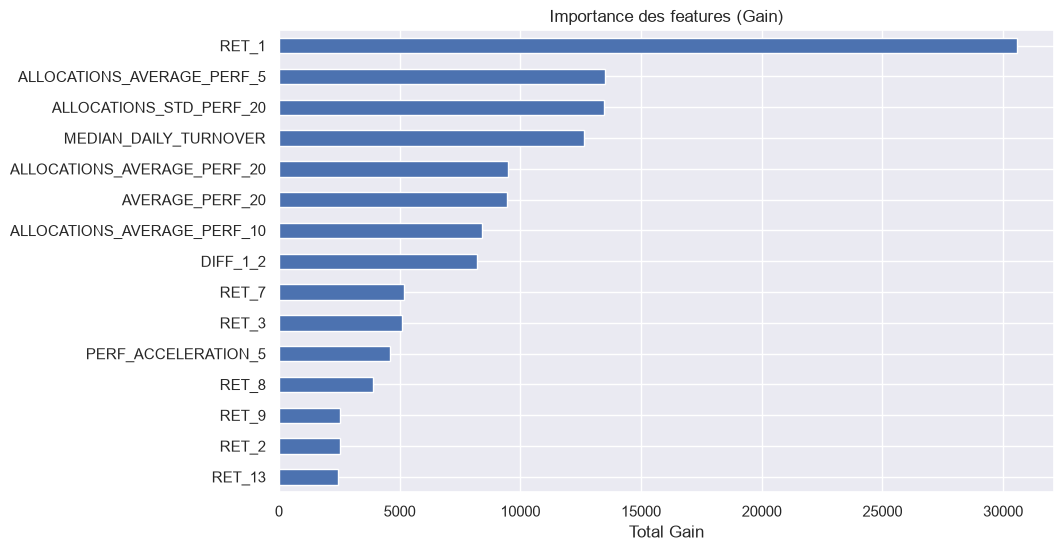

In [231]:
feature_imp = pd.Series(
    model.feature_importance(importance_type="gain"), 
    index=X_train_clean.columns
).sort_values(ascending=False)

# Affichage des 15 variables les plus importantes
plt.figure(figsize=(10, 6))
feature_imp.head(15).plot(kind="barh").invert_yaxis()
plt.title("Importance des features (Gain)")
plt.xlabel("Total Gain")
plt.show()

In [202]:
top_8_features = feature_imp.head(8).index.tolist()

In [203]:
scores_top8=[]
for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(cv_splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train["TS"].isin(local_train_dates)
    local_test_ids = X_train["TS"].isin(local_test_dates)

    # Filtrage strict sur les 8 features
    X_local_train = X_train_clean.loc[local_train_ids, top_8_features]
    y_local_train = y_train_clean.loc[local_train_ids]
    y_local_train_bin = (y_local_train > 0).astype(int)

    X_local_test = X_train_clean.loc[local_test_ids, top_8_features]
    y_local_test = y_train_clean.loc[local_test_ids]
    y_local_test_bin = (y_local_test > 0).astype(int)

    train_data = lgbm.Dataset(X_local_train, label=y_local_train_bin.values)
    model = lgbm.train(
        lgbm_params,
        train_data,
        num_boost_round=NUM_BOOST_ROUND,
    )

    y_local_pred = model.predict(X_local_test.values)
    score = accuracy_score(y_local_test_bin, (y_local_pred > 0.5).astype(int))
    scores_top8.append(score)
    print(f"Fold {i+1} - Accuracy (Top 8): {score * 100:.2f}%")

print(
    f"\n---> LightGBM (Top 8) Accuracy moyenne: {np.mean(scores_top8) * 100:.2f}% (+- {np.std(scores_top8) * 100:.2f}%)"
)

Fold 1 - Accuracy (Top 8): 52.03%
Fold 2 - Accuracy (Top 8): 52.78%
Fold 3 - Accuracy (Top 8): 51.99%
Fold 4 - Accuracy (Top 8): 52.78%
Fold 5 - Accuracy (Top 8): 51.90%
Fold 6 - Accuracy (Top 8): 52.29%
Fold 7 - Accuracy (Top 8): 52.54%
Fold 8 - Accuracy (Top 8): 52.44%

---> LightGBM (Top 8) Accuracy moyenne: 52.34% (+- 0.33%)


In [204]:
print(top_8_features)

['RET_1', 'ALLOCATIONS_AVERAGE_PERF_5', 'ALLOCATIONS_STD_PERF_20', 'MEDIAN_DAILY_TURNOVER', 'ALLOCATIONS_AVERAGE_PERF_20', 'AVERAGE_PERF_20', 'ALLOCATIONS_AVERAGE_PERF_10', 'DIFF_1_2']


In [ ]:
scores_topX=[]
featuresX=['RET_1', 'ALLOCATIONS_AVERAGE_PERF_5', 'ALLOCATIONS_STD_PERF_20', 'MEDIAN_DAILY_TURNOVER', 'ALLOCATIONS_AVERAGE_PERF_20', 'AVERAGE_PERF_20', 'ALLOCATIONS_AVERAGE_PERF_10', 'DIFF_1_2', 'RET_2', 'W_AVERAGE_PERF_10', 'W_AVERAGE_PERF_20', 'COUNT_POS_RET_20']
for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(cv_splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train["TS"].isin(local_train_dates)
    local_test_ids = X_train["TS"].isin(local_test_dates)

    # Filtrage strict sur les 8 features
    X_local_train = X_train_clean.loc[local_train_ids, featuresX]
    y_local_train = y_train_clean.loc[local_train_ids]
    y_local_train_bin = (y_local_train > 0).astype(int)

    X_local_test = X_train_clean.loc[local_test_ids, featuresX]
    y_local_test = y_train_clean.loc[local_test_ids]
    y_local_test_bin = (y_local_test > 0).astype(int)

    train_data = lgbm.Dataset(X_local_train, label=y_local_train_bin.values)
    model = lgbm.train(
        lgbm_params,
        train_data,
        num_boost_round=NUM_BOOST_ROUND,
    )

    y_local_pred = model.predict(X_local_test.values)
    score = accuracy_score(y_local_test_bin, (y_local_pred > 0.5).astype(int))
    scores_topX.append(score)
    print(f"Fold {i+1} - Accuracy (Top 8): {score * 100:.2f}%")

print(
    f"\n---> LightGBM (Top 8) Accuracy moyenne: {np.mean(scores_topX) * 100:.2f}% (+- {np.std(scores_topX) * 100:.2f}%)"
)

Fold 1 - Accuracy (Top 8): 52.24%
Fold 2 - Accuracy (Top 8): 52.65%
Fold 3 - Accuracy (Top 8): 52.11%
Fold 4 - Accuracy (Top 8): 52.60%
Fold 5 - Accuracy (Top 8): 51.88%
Fold 6 - Accuracy (Top 8): 52.38%
Fold 7 - Accuracy (Top 8): 52.55%
Fold 8 - Accuracy (Top 8): 52.23%

---> LightGBM (Top 8) Accuracy moyenne: 52.33% (+- 0.25%)


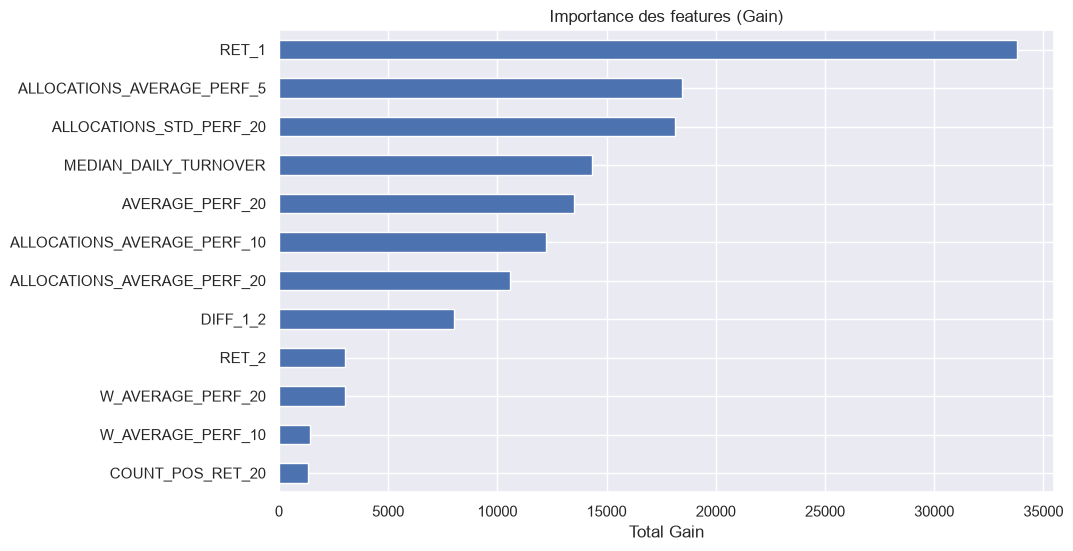

In [ ]:
feature_imp = pd.Series(
    model.feature_importance(importance_type="gain"), 
    index=X_train_clean[featuresX].columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_imp.head(13).plot(kind="barh").invert_yaxis()
plt.title("Importance des features (Gain)")
plt.xlabel("Total Gain")
plt.show()

In [142]:
xgboost_param={
    'objective': 'reg:squarederror',
    'eval_metric': 'error',
    "learning_rate":0.01,
    "max_depth":5,
    "reg_lambda":5,
    "reg_alpha":0.5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1
}

NUM_BOOST_ROUND = 500

scores_xgb = []

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(cv_splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train_clean.loc[local_train_ids]
    y_local_train = y_train_clean.loc[local_train_ids]

    X_local_test = X_train_clean.loc[local_test_ids]
    y_local_test = y_train_clean.loc[local_test_ids]

    dtrain = xgb.DMatrix(X_local_train, label=y_local_train.values)
    dtest = xgb.DMatrix(X_local_test, label=y_local_test.values)

    model_xgb = xgb.train(xgboost_param, dtrain, num_boost_round=NUM_BOOST_ROUND)

    y_local_pred = model_xgb.predict(dtest)

    score = accuracy_score((y_local_test > 0).astype(int), (y_local_pred > 0).astype(int))
    scores_xgb.append(score)
    print(f"XGB Fold {i+1} - Accuracy: {score * 100:.2f}%")

mean_score_xgb = np.mean(scores_xgb) * 100
std_score_xgb = np.std(scores_xgb) * 100
print(f"\n---> XGBoost régularisé Accuracy moyenne: {mean_score_xgb:.2f}% (+- {std_score_xgb:.2f}%)")

XGB Fold 1 - Accuracy: 52.13%
XGB Fold 2 - Accuracy: 52.65%
XGB Fold 3 - Accuracy: 52.00%
XGB Fold 4 - Accuracy: 52.65%
XGB Fold 5 - Accuracy: 51.87%
XGB Fold 6 - Accuracy: 52.53%
XGB Fold 7 - Accuracy: 52.34%
XGB Fold 8 - Accuracy: 52.08%

---> XGBoost régularisé Accuracy moyenne: 52.28% (+- 0.28%)


In [252]:
xgboost_param_logistic={
    'objective': 'binary:logistic',
    'eval_metric': 'error',
    "learning_rate":0.01,
    "max_depth":3,
    "reg_lambda":25,
    "reg_alpha":10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'min_child_weight':100,
    'gamma':1,
    
}

NUM_BOOST_ROUND = 500

scores_xgb = []

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(cv_splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train_clean.loc[local_train_ids]
    y_local_train = y_train_clean.loc[local_train_ids]

    X_local_test = X_train_clean.loc[local_test_ids]
    y_local_test = y_train_clean.loc[local_test_ids]
    
    y_local_train_bin = (y_local_train > 0).astype(int)
    y_local_test_bin = (y_local_test > 0).astype(int)

    dtrain = xgb.DMatrix(X_local_train, label=y_local_train_bin.values)
    dtest = xgb.DMatrix(X_local_test, label=y_local_test_bin.values)

    model_xgb_logistic = xgb.train(xgboost_param_logistic, dtrain, num_boost_round=NUM_BOOST_ROUND)

    y_local_pred = model_xgb_logistic.predict(dtest)

    score = accuracy_score((y_local_test > 0).astype(int), (y_local_pred > 0.5).astype(int))
    scores_xgb.append(score)
    print(f"XGB Fold {i+1} - Accuracy: {score * 100:.2f}%")

mean_score_xgb = np.mean(scores_xgb) * 100
std_score_xgb = np.std(scores_xgb) * 100
print(f"\n---> XGBoost régularisé Accuracy moyenne: {mean_score_xgb:.2f}% (+- {std_score_xgb:.2f}%)")

XGB Fold 1 - Accuracy: 52.35%
XGB Fold 2 - Accuracy: 52.68%
XGB Fold 3 - Accuracy: 52.25%
XGB Fold 4 - Accuracy: 52.74%
XGB Fold 5 - Accuracy: 52.20%
XGB Fold 6 - Accuracy: 52.83%
XGB Fold 7 - Accuracy: 52.17%
XGB Fold 8 - Accuracy: 52.22%

---> XGBoost régularisé Accuracy moyenne: 52.43% (+- 0.26%)


In [144]:
catboost_params = {
    'loss_function': 'Logloss',
    'eval_metric': 'Accuracy',
    'learning_rate': 0.01,
    'depth': 5,
    'l2_leaf_reg': 5,
    'random_seed': 42,
    'verbose': False,
    'thread_count': -1
}

y_local_train_bin = (y_local_train > 0).astype(int)
y_local_test_bin = (y_local_test > 0).astype(int)

NUM_BOOST_ROUND = 500

scores_cat = []

for i, (local_train_dates_ids, local_test_dates_ids) in enumerate(cv_splits):
    local_train_dates = train_dates[local_train_dates_ids]
    local_test_dates = train_dates[local_test_dates_ids]

    local_train_ids = X_train['TS'].isin(local_train_dates)
    local_test_ids = X_train['TS'].isin(local_test_dates)

    X_local_train = X_train_clean.loc[local_train_ids]
    y_local_train = y_train_clean.loc[local_train_ids]

    X_local_test = X_train_clean.loc[local_test_ids]
    y_local_test = y_train_clean.loc[local_test_ids]
    
    y_local_train_bin = (y_local_train > 0).astype(int)
    y_local_test_bin = (y_local_test > 0).astype(int)

    model_cat = CatBoostClassifier(
        **catboost_params,
        iterations=NUM_BOOST_ROUND
    )
    
    model_cat.fit(
        X_local_train,
        y_local_train_bin
    )

    y_local_pred = model_cat.predict_proba(X_local_test)[:, 1]

    score = accuracy_score((y_local_test > 0).astype(int), (y_local_pred > 0.5).astype(int))
    scores_cat.append(score)
    print(f"Cat Fold {i+1} - Accuracy: {score * 100:.2f}%")

mean_score_cat = np.mean(scores_cat) * 100
std_score_cat = np.std(scores_cat) * 100
print(f"\n---> CatBoost régularisé Accuracy moyenne: {mean_score_cat:.2f}% (+- {std_score_cat:.2f}%)")

Cat Fold 1 - Accuracy: 52.40%
Cat Fold 2 - Accuracy: 52.74%
Cat Fold 3 - Accuracy: 52.21%
Cat Fold 4 - Accuracy: 52.79%
Cat Fold 5 - Accuracy: 51.95%
Cat Fold 6 - Accuracy: 52.64%
Cat Fold 7 - Accuracy: 52.41%
Cat Fold 8 - Accuracy: 52.26%

---> CatBoost régularisé Accuracy moyenne: 52.43% (+- 0.27%)


In [29]:
sample_submission = pd.read_csv('sample_submission_SpGVFuH.csv',index_col='ROW_ID')

In [155]:
train_data = lgbm.Dataset(X_train_clean[features], label=y_train) 

model_lgbm = lgbm.train(lgbm_params, train_data,num_boost_round=NUM_BOOST_ROUND) 
preds_lgbm = model_lgbm.predict(X_test_clean[features])
preds_lgbm = pd.DataFrame(preds_lgbm, index=sample_submission.index,columns=['target']) 


In [156]:
(preds_lgbm>0).astype(int).to_csv('preds_lgbm_bench.csv')

In [ ]:
y_train_clean_bin = (y_train_clean > 0).astype(int)

train_data = xgb.DMatrix(X_train[features], label=y_train_clean_bin.values) 

model_xgb = xgb.train(xgboost_param_logistic, train_data,num_boost_round=NUM_BOOST_ROUND) 
preds_xgb = model_xgb.predict(X_test[features])
preds_xgb = pd.DataFrame(preds_xgb, index=sample_submission.index,columns=['target']) 


In [32]:
(preds_xgb>0.5).astype(int).to_csv('preds_xgb_bench.csv')

In [161]:
y_train_clean_bin = (y_train_clean > 0).astype(int)

model_cat = CatBoostClassifier(
        **catboost_params,
        iterations=NUM_BOOST_ROUND
    )
model_cat.fit(
        X_train_clean,
        y_train_clean_bin
    )
y_pred = model_cat.predict_proba(X_test_clean)[:, 1]

preds_cat = pd.DataFrame(y_pred, index=sample_submission.index,columns=['target']) 


In [162]:
(preds_cat>0.5).astype(int).to_csv('preds_cat_bench.csv')